# 🏀 NBA Shot Success Prediction Project

This project aims to build a machine learning model that predicts whether a basketball shot will be made or missed based on contextual and gameplay data. We will go through the complete pipeline from data preprocessing and feature engineering, to visualization, model training, and evaluation.

## 📚 Table of Contents
- 1. Introduction
- 2. Data Loading
- 3. Data Cleaning & Missing Value Handling
- 4. Feature Engineering
- 5. Principal Component Analysis (PCA) & Exploratory Data Analysis (EDA)
- 6. Model Training and Evaluation
    - 6.1 Logistic Regression
    - 6.2 Random Forest Classifier
    - 6.3 Neural Network
- 7. Summary & Next Steps

## 1. Introduction
In this project, we aim to build a machine learning model to predict whether a basketball shot will be made or missed using contextual and gameplay data.

## 2. Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("merged_shot_data_partial 2.csv")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18817 entries, 0 to 18816
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   GAME_ID           18817 non-null  int64  
 1   player_name       18817 non-null  object 
 2   PERIOD            18817 non-null  int64  
 3   GAME_CLOCK        18817 non-null  object 
 4   SHOT_CLOCK        17733 non-null  float64
 5   DRIBBLES          18817 non-null  int64  
 6   TOUCH_TIME        18817 non-null  float64
 7   PTS_TYPE          18817 non-null  int64  
 8   SHOT_RESULT       18817 non-null  object 
 9   CLOSEST_DEFENDER  18817 non-null  object 
 10  CLOSE_DEF_DIST    18817 non-null  float64
 11  FGM               18817 non-null  int64  
 12  PTS               18817 non-null  int64  
 13  ACTION_TYPE       18817 non-null  object 
 14  SHOT_ZONE_AREA    18817 non-null  object 
 15  SHOT_ZONE_RANGE   18817 non-null  object 
 16  SHOT_DISTANCE     18817 non-null  int64 

,GAME_ID,player_name,PERIOD,GAME_CLOCK,SHOT_CLOCK,DRIBBLES,TOUCH_TIME,PTS_TYPE,SHOT_RESULT,CLOSEST_DEFENDER,CLOSE_DEF_DIST,FGM,PTS,ACTION_TYPE,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y
0,21400899,brian roberts,1,1:09,10.8,2,1.9,2,made,"Anderson, Alan",1.3,1,2,Driving Jump shot,Right Side(R),8-16 ft.,9,53,78
1,21400899,brian roberts,1,0:14,3.4,0,0.8,3,missed,"Bogdanovic, Bojan",6.1,0,0,Jump Shot,Right Side Center(RC),24+ ft.,29,144,255
2,21400899,brian roberts,1,0:00,NaN,3,2.7,2,missed,"Bogdanovic, Bojan",0.9,0,0,Floating Jump shot,Center(C),Less Than 8 ft.,6,32,55
3,21400899,brian roberts,2,11:47,10.3,2,1.9,2,missed,"Brown, Markel",3.4,0,0,Jump Shot,Center(C),16-24 ft.,18,4,183
4,21400899,brian roberts,2,10:34,10.9,2,2.7,2,missed,"Young, Thaddeus",1.1,0,0,Driving Layup Shot,Center(C),Less Than 8 ft.,1,15,6


## 3. Data Cleaning & Missing Value Handling


We noticed that `SHOT_CLOCK` has missing values. Instead of filling them with a central tendency value like median, we analyzed the context and found that they typically occur during the final seconds of a game. Therefore, we chose to fill them with `0` to reflect that these were likely rushed or buzzer-beater shots.

---

We also removed outliers based on domain knowledge:
- **SHOT_DISTANCE > 40**: Half-court or beyond, rarely attempted.
- **CLOSE_DEF_DIST < 0 or > 15**: Likely error or irrelevant spacing.
- **DRIBBLES > 30** or **TOUCH_TIME > 24s**: Unrealistic during real play.
- **LOC_X not in [-300, 300]** or **LOC_Y not in [0, 500]**: Outside NBA court.


In [3]:
df['SHOT_CLOCK'] = df['SHOT_CLOCK'].fillna(0)

### 3.1 Outlier Detection and Removal

In [4]:
df.shape

(18817, 19)

In [5]:
df = df[df['SHOT_DISTANCE'] <= 40]
df = df[(df['CLOSE_DEF_DIST'] >= 0) & (df['CLOSE_DEF_DIST'] <= 15)]
df = df[df['DRIBBLES'] <= 30]
df = df[df['TOUCH_TIME'] <= 24]
df = df[(df['LOC_X'].between(-300, 300)) & (df['LOC_Y'].between(0, 500))]

In [6]:
df.shape

(17866, 19)

In [7]:
df.head()

,GAME_ID,player_name,PERIOD,GAME_CLOCK,SHOT_CLOCK,DRIBBLES,TOUCH_TIME,PTS_TYPE,SHOT_RESULT,CLOSEST_DEFENDER,CLOSE_DEF_DIST,FGM,PTS,ACTION_TYPE,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y
0,21400899,brian roberts,1,1:09,10.8,2,1.9,2,made,"Anderson, Alan",1.3,1,2,Driving Jump shot,Right Side(R),8-16 ft.,9,53,78
1,21400899,brian roberts,1,0:14,3.4,0,0.8,3,missed,"Bogdanovic, Bojan",6.1,0,0,Jump Shot,Right Side Center(RC),24+ ft.,29,144,255
2,21400899,brian roberts,1,0:00,0.0,3,2.7,2,missed,"Bogdanovic, Bojan",0.9,0,0,Floating Jump shot,Center(C),Less Than 8 ft.,6,32,55
3,21400899,brian roberts,2,11:47,10.3,2,1.9,2,missed,"Brown, Markel",3.4,0,0,Jump Shot,Center(C),16-24 ft.,18,4,183
4,21400899,brian roberts,2,10:34,10.9,2,2.7,2,missed,"Young, Thaddeus",1.1,0,0,Driving Layup Shot,Center(C),Less Than 8 ft.,1,15,6


## 4. Feature Engineering


### 🛠️ Feature Engineering Explanation

To help our model better understand the context of each shot, we created several **engineered features**:

- `GAME_CLOCK_SEC`: Transforms `GAME_CLOCK` (MM:SS) into total seconds.
- `IS_BUZZER`: Indicates a buzzer-beater shot (shot clock < 3s and game clock < 5s).
- `MID_RANGE`: True if shot distance is between 8 and 16 feet.
- `OPEN_SHOT`: True if defender is more than 6 feet away.
- `SHOT_ANGLE_DEG`: The angle of the shot relative to the basket (left vs center vs right), calculated using arctangent of X/Y.
- `TIME_REMAINING`: Total time remaining in the game (in seconds).
- `IS_END_OF_QUARTER`: Whether the shot was taken in the last 24 seconds of the quarter.
- `IS_FAST_BREAK`: Indicates a fast break shot (few dribbles and short touch time).
- `IS_LONG_SHOT`: Identifies long-distance shots (e.g., beyond the 3-point line).
- `DEFENDER_DISTANCE_BUCKET`: Categorical defense pressure based on defender distance.
- `DISTANCE_FROM_CENTER`: Euclidean distance from the basket.
- `EFFORT_INDEX`: A proxy for effort using dribbles and touch time.
- `CLUTCH_THREE`: A flag for 3-point shots taken in clutch time (last 24s).


In [8]:
import pandas as pd
import numpy as np

# Load data and drop irrelevant columns
# df = pd.read_csv("merged_shot_data.csv")
df = df.drop(columns=["GAME_ID", "player_name", "CLOSEST_DEFENDER", "FGM", "PTS"], errors="ignore")

# Ensure coordinates are numeric
df['LOC_X'] = pd.to_numeric(df['LOC_X'], errors='coerce')
df['LOC_Y'] = pd.to_numeric(df['LOC_Y'], errors='coerce')

clock_split = df['GAME_CLOCK'].str.extract(r'(\d+):(\d+)')
df['GAME_CLOCK'] = clock_split[0].astype(float) * 60 + clock_split[1].astype(float)

df['TIME_REMAINING'] = df['PERIOD'] * 720 - df['GAME_CLOCK']

df['IS_BUZZER'] = ((df['SHOT_CLOCK'] < 3) & (df['GAME_CLOCK'] < 5)).astype(float)

df['IS_END_OF_QUARTER'] = (df['GAME_CLOCK'] < 24).astype(float)

df['IS_FAST_BREAK'] = ((df['DRIBBLES'] <= 1) & (df['TOUCH_TIME'] <= 2)).astype(float)

df['IS_LONG_SHOT'] = (df['SHOT_DISTANCE'] > 24).astype(float)

df['MID_RANGE'] = ((df['SHOT_DISTANCE'] >= 8) & (df['SHOT_DISTANCE'] <= 16)).astype(float)

df['OPEN_SHOT'] = (df['CLOSE_DEF_DIST'] > 6).astype(float)

df['DISTANCE_FROM_CENTER'] = np.sqrt(df['LOC_X']**2 + df['LOC_Y']**2)

df['EFFORT_INDEX'] = df['DRIBBLES'] * df['TOUCH_TIME']

df['CLUTCH_THREE'] = ((df['PTS_TYPE'] == 3) & (df['GAME_CLOCK'] < 24)).astype(float)

df['SHOT_ANGLE_DEG'] = np.degrees(np.arctan2(df['LOC_X'], df['LOC_Y']))

df['DEFENDER_DISTANCE_BUCKET'] = pd.cut(df['CLOSE_DEF_DIST'],
    bins=[-1, 2, 4, 6, 15],
    labels=['Tightly Guarded', 'Contested', 'Open', 'Wide Open']
)

# One-hot encode selected categorical features (excluding the target)
categorical_cols = ['ACTION_TYPE', 'SHOT_ZONE_AREA',
                    'SHOT_ZONE_RANGE', 'DEFENDER_DISTANCE_BUCKET']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

# Convert SHOT_RESULT to binary if it's string-based
if df['SHOT_RESULT'].dtype == 'object':
    df['SHOT_RESULT'] = df['SHOT_RESULT'].map({'made': 1, 'missed': 0})

# Final checks
print(df.shape)
print(df[['SHOT_RESULT']].value_counts())

(17866, 82)
SHOT_RESULT
0              9881
1              7985
Name: count, dtype: int64


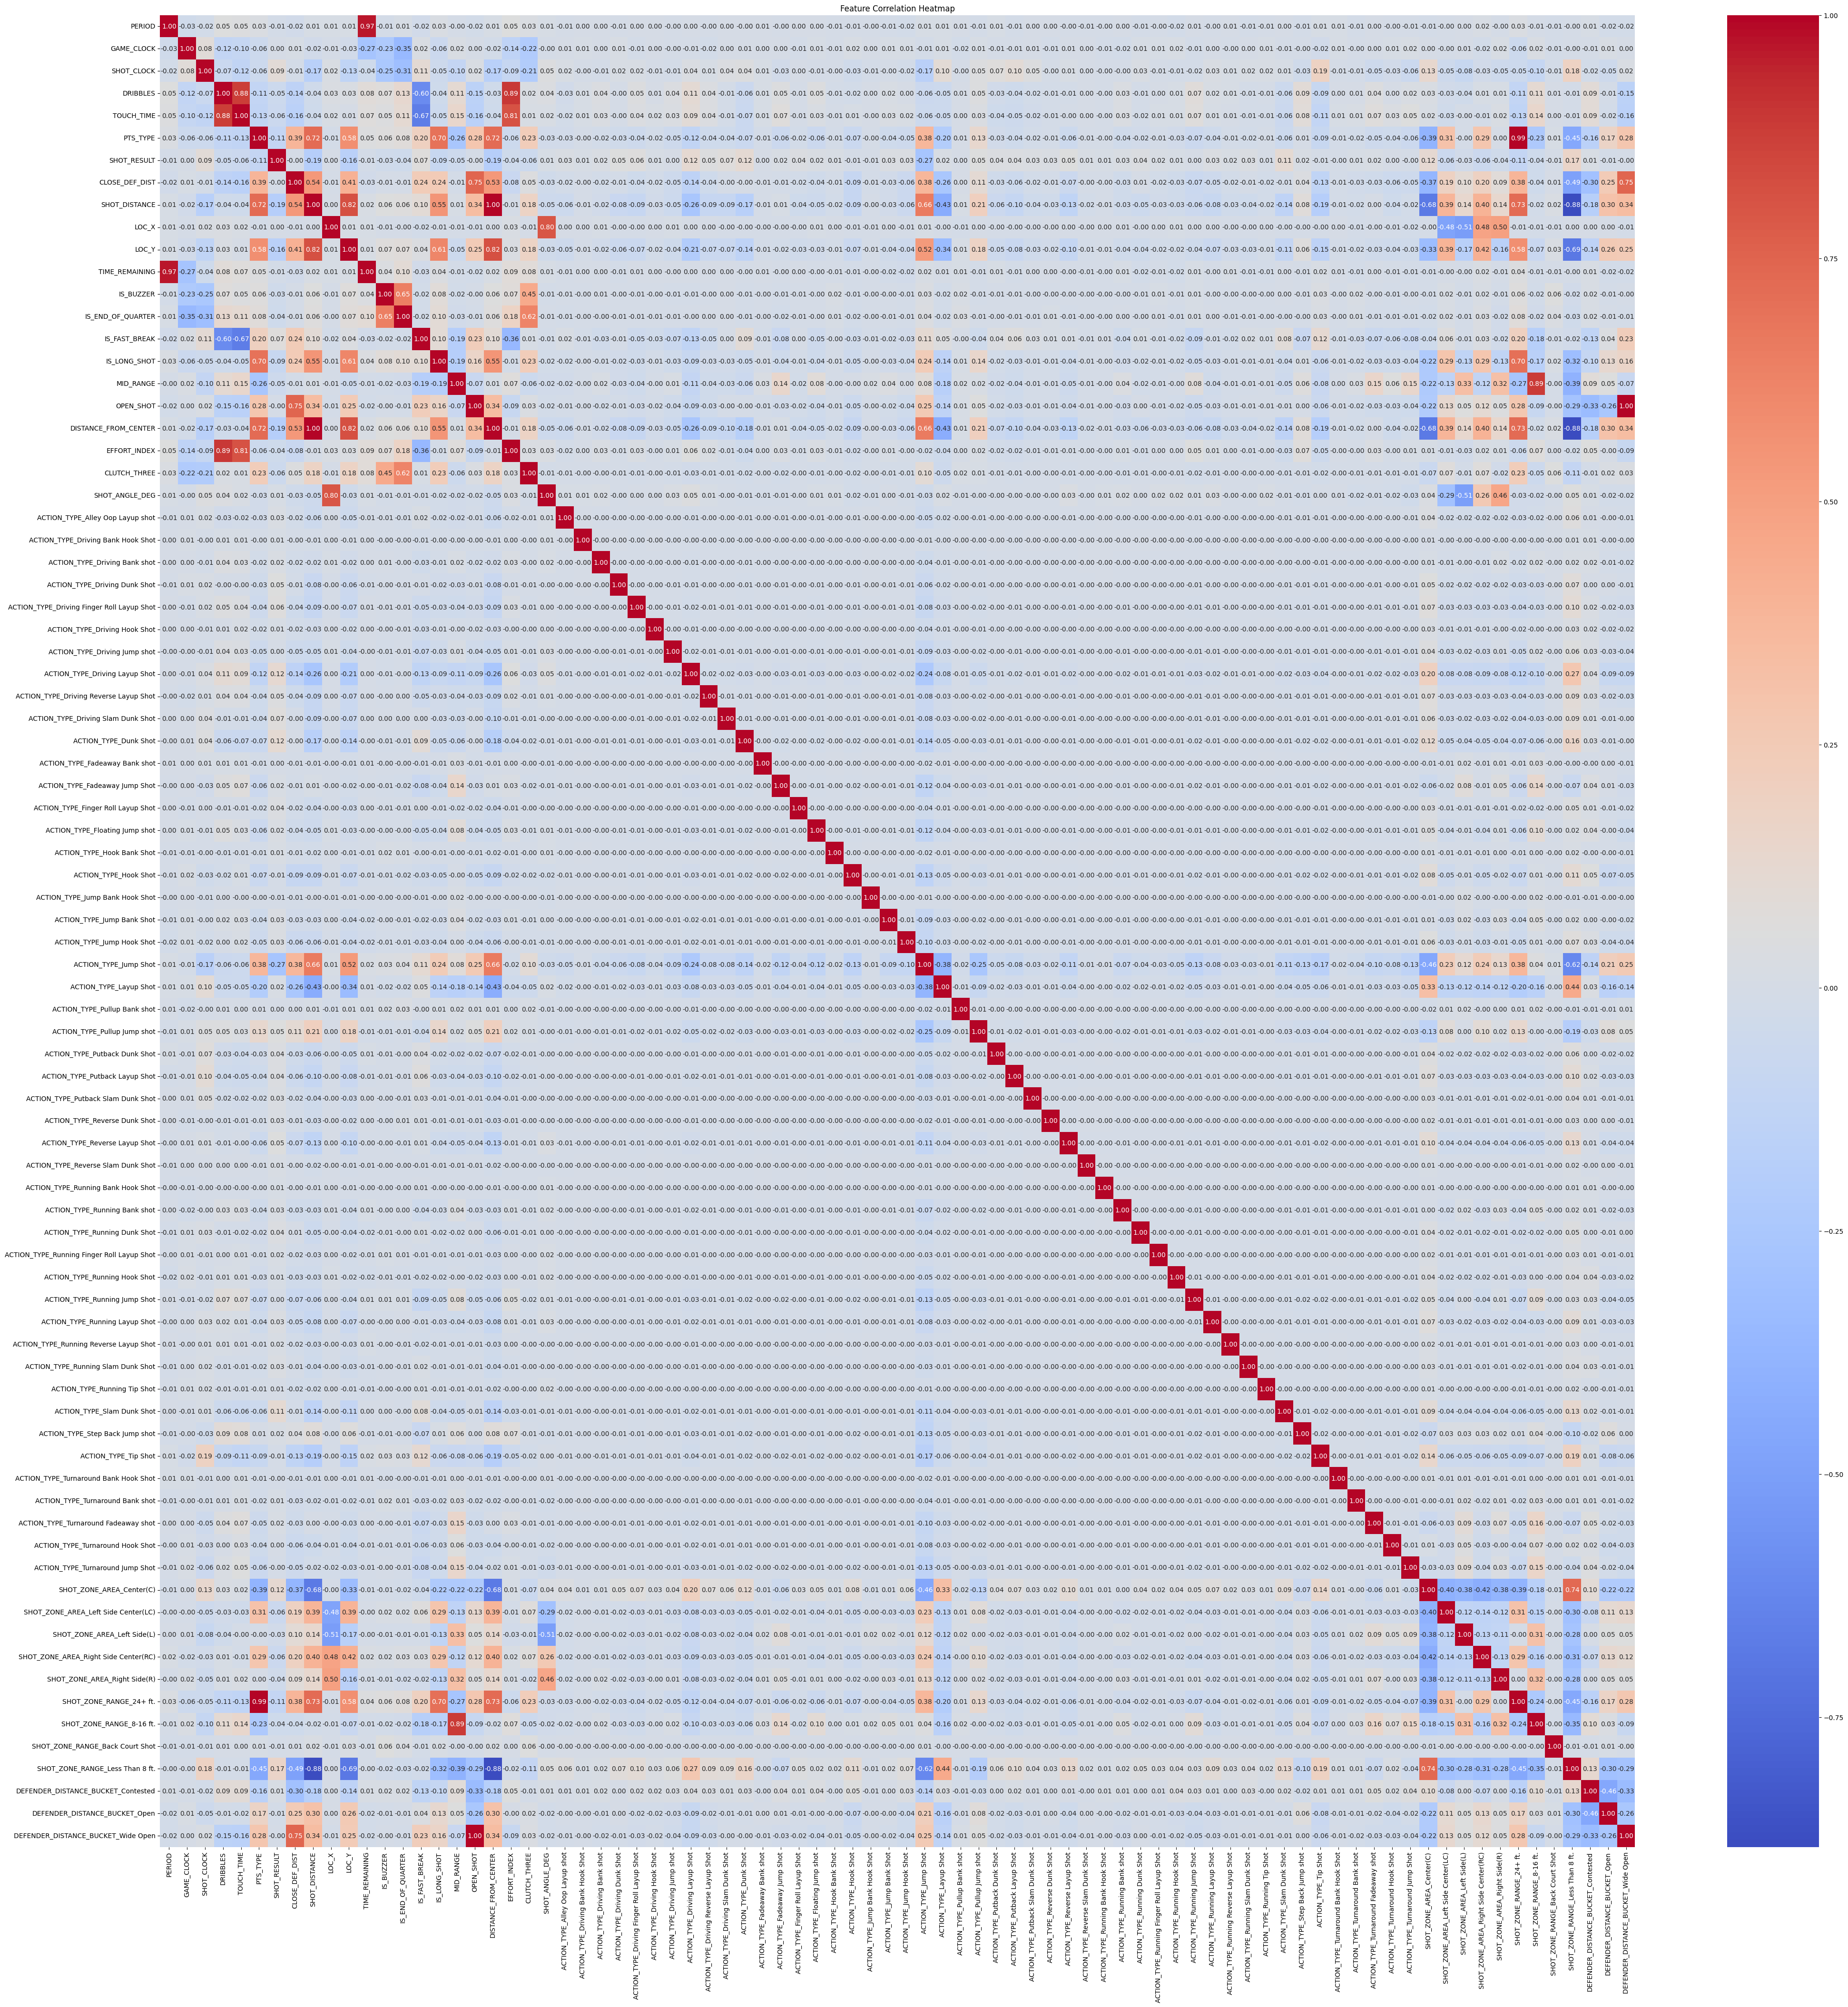

Top 10 features most correlated with SHOT_RESULT:

ACTION_TYPE_Jump Shot             -0.266113
DISTANCE_FROM_CENTER              -0.189296
SHOT_DISTANCE                     -0.187757
SHOT_ZONE_RANGE_Less Than 8 ft.    0.167320
LOC_Y                             -0.163406
ACTION_TYPE_Driving Layup Shot     0.121984
SHOT_ZONE_AREA_Center(C)           0.121451
ACTION_TYPE_Dunk Shot              0.116781
ACTION_TYPE_Slam Dunk Shot         0.114535
PTS_TYPE                          -0.110367
Name: SHOT_RESULT, dtype: float64


In [9]:
# 📊 Correlation Heatmap (after Feature Engineering)
plt.figure(figsize=(50, 50))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

# 🔍 Top 10 Most Correlated Features with SHOT_RESULT

# Compute correlation with the target (excluding itself)
target_corr = corr['SHOT_RESULT'].drop('SHOT_RESULT', errors='ignore').sort_values(key=abs, ascending=False)

# Show top 10 features most correlated with SHOT_RESULT (by absolute value)
print("Top 10 features most correlated with SHOT_RESULT:\n")
print(target_corr.head(10))

## 5. Principal Component Analysis (PCA) & Exploratory Data Analysis (EDA)

In this section, we begin by applying **Principal Component Analysis (PCA)** to gain insight into the structure and distribution of the dataset in reduced dimensions. Following that, we use various visualizations to explore relationships between shot features and success outcomes.

### Subsections:

5.1 **PCA: Principal Component Analysis of Shot Features**  
Reduces high-dimensional shot data into principal components for visualization and interpretation. This helps identify key patterns and variance drivers before performing detailed feature-level analysis.

5.2 **Shot Outcome Scatter Plot on Half Court**  
Visualizes the spatial distribution of made and missed shots on a half-court layout.

5.3 **Shot Success Rate by Distance**  
Analyzes how shot distance from the basket correlates with success rate.

5.4 **Shot Success Rate by Defender Distance**  
Assesses how defender proximity influences shot-making performance.

5.5 **Shot Success Rate by Shot Angle**  
Evaluates shot outcome based on the horizontal angle from the basket.

5.6 **Top Action Types by Frequency**  
Displays the most frequently occurring shot types in the dataset.

### 🎯 5.1 PCA: Principal Component Analysis of Shot Features

After examining the correlation heatmap of all features, we identified that some features exhibit strong multicollinearity, although their individual correlation with the target variable (SHOT_RESULT) is relatively low. Despite this, we decided to experiment with Principal Component Analysis (PCA) to see if it could help extract more informative features.

To do this, we first isolated the subset of features that were highly correlated with each other (correlation coefficient > 0.7), standardized them using StandardScaler, and applied PCA to reduce them into five principal components.


In [10]:
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.85)]
X_high_corr = df[high_corr_cols]
X_high_corr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17866 entries, 0 to 18816
Data columns (total 7 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   TOUCH_TIME                          17866 non-null  float64
 1   TIME_REMAINING                      17866 non-null  float64
 2   DISTANCE_FROM_CENTER                17866 non-null  float64
 3   EFFORT_INDEX                        17866 non-null  float64
 4   SHOT_ZONE_RANGE_24+ ft.             17866 non-null  int64  
 5   SHOT_ZONE_RANGE_8-16 ft.            17866 non-null  int64  
 6   DEFENDER_DISTANCE_BUCKET_Wide Open  17866 non-null  int64  
dtypes: float64(4), int64(3)
memory usage: 1.1 MB


In [11]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

features = X_high_corr
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

pca = PCA(n_components=5)
principal_components = pca.fit_transform(features_scaled)
principal_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])
principal_df.head()

,PC1,PC2,PC3,PC4,PC5
0,-0.894136,-0.848357,-1.977593,1.134669,-0.426480
1,3.109028,1.207409,-1.004559,-0.420739,0.890335
2,-0.595624,-0.762412,-0.187600,-0.926418,-0.081891
3,0.149939,-0.417004,-0.392585,-0.678559,-0.426769
4,-0.802620,-1.007303,-0.021612,-0.925317,0.051725


In [12]:
principal_df.shape

(17866, 5)

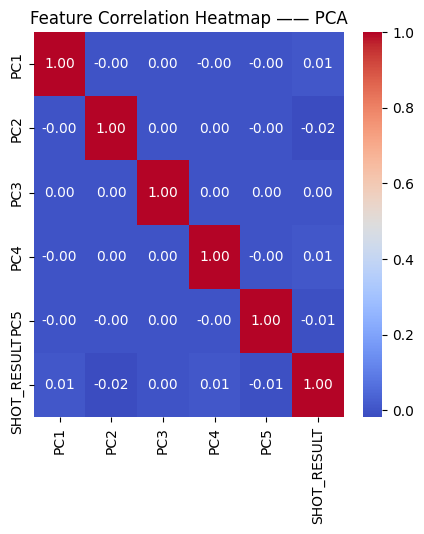

In [13]:
# 📊 Correlation Heatmap (after PCA)
df_pca = pd.concat([principal_df, df['SHOT_RESULT']], axis=1)
plt.figure(figsize=(5, 5))
corr = df_pca.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap —— PCA')
plt.show()

In [14]:
df_pca.shape

(18745, 6)

However, after generating the new features (PC1 to PC5), we observed that their correlation with the target variable remained very low—often even lower than the original features. This indicated that the PCA-transformed features did not improve the predictive relationship with the target.

As a result, we decided not to use the PCA features for our final model. Instead, we selected the top 10 features with the highest direct correlation to the target and used them for model training, as they retained more meaningful information for the classification task.


### 🎯 5.2 Shot Outcome Scatter Plot on Half Court

This plot overlays a **realistic basketball half-court** with each shot attempt, showing **made vs missed shots**:
- 🟢 Green = Made
- 🔴 Red = Missed

This is useful for identifying which zones players are most successful or struggle in.


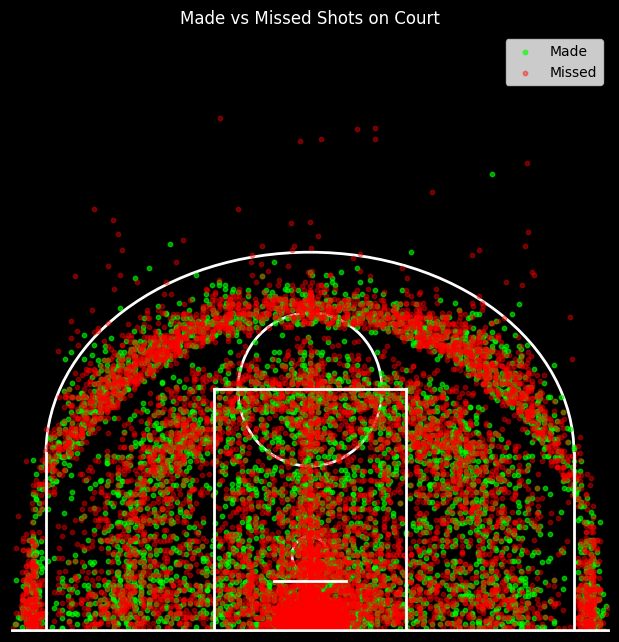

In [15]:
import matplotlib as mpl

# Scatter plot of made vs missed shots
fig = plt.figure(figsize=(6, 6), facecolor='black', dpi=100)
ax = fig.add_axes([0, 0, 1, 1], facecolor='black')

# Draw simplified half court
ax.plot([-220, -220], [0, 140], linewidth=2, color='white')
ax.plot([220, 220], [0, 140], linewidth=2, color='white')
ax.add_artist(mpl.patches.Arc((0, 140), 440, 315, theta1=0, theta2=180, edgecolor='white', lw=2))
ax.plot([-80, -80], [0, 190], linewidth=2, color='white')
ax.plot([80, 80], [0, 190], linewidth=2, color='white')
ax.plot([-80, 80], [190, 190], linewidth=2, color='white')
ax.add_artist(mpl.patches.Circle((0, 190), 60, edgecolor='white', facecolor='none', lw=2))
ax.plot([-250, 250], [0, 0], linewidth=4, color='white')
ax.add_artist(mpl.patches.Circle((0, 60), 15, edgecolor='white', facecolor='none', lw=2))
ax.plot([-30, 30], [40, 40], linewidth=2, color='white')

# Scatter made/missed
made = df[df['SHOT_RESULT'] == 1]
missed = df[df['SHOT_RESULT'] == 0]
ax.scatter(made['LOC_X'], made['LOC_Y'], c='lime', s=10, alpha=0.6, label='Made')
ax.scatter(missed['LOC_X'], missed['LOC_Y'], c='red', s=10, alpha=0.4, label='Missed')

ax.set_xlim(-250, 250)
ax.set_ylim(0, 470)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Made vs Missed Shots on Court", color='white')
ax.legend(loc='upper right')
plt.show()


### 5.3 Shot Success Rate by Distance

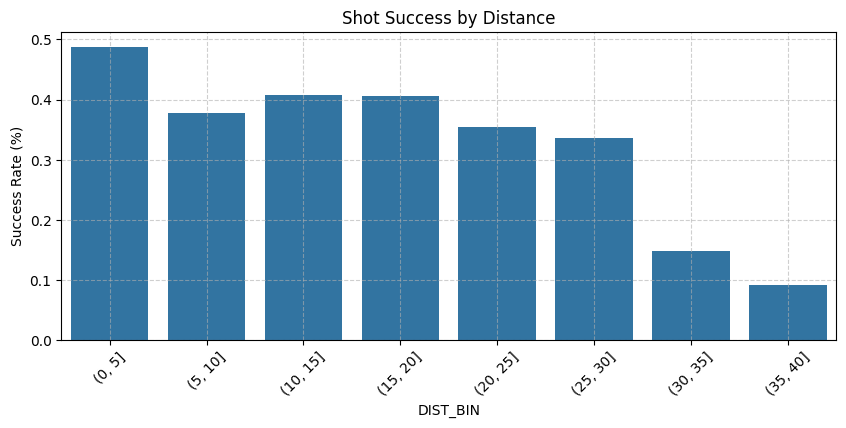

In [16]:
df['DIST_BIN'] = pd.cut(df['SHOT_DISTANCE'], bins=range(0, 45, 5))
distance_success = df.groupby('DIST_BIN', observed=True)['SHOT_RESULT'].mean().reset_index()
plt.figure(figsize=(10, 4))
sns.barplot(x='DIST_BIN', y='SHOT_RESULT', data=distance_success)
plt.xticks(rotation=45)
plt.title('Shot Success by Distance')
plt.ylabel('Success Rate (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


**Why this chart?**  
We analyze how shot success varies with distance from the basket.

**What we see:**  
The success rate generally decreases as the distance increases, which aligns with common basketball intuition.

**Conclusion:**  
`SHOT_DISTANCE` is a strong predictor for whether a shot will be successful.


### 5.4 Shot Success Rate by Defender Distance

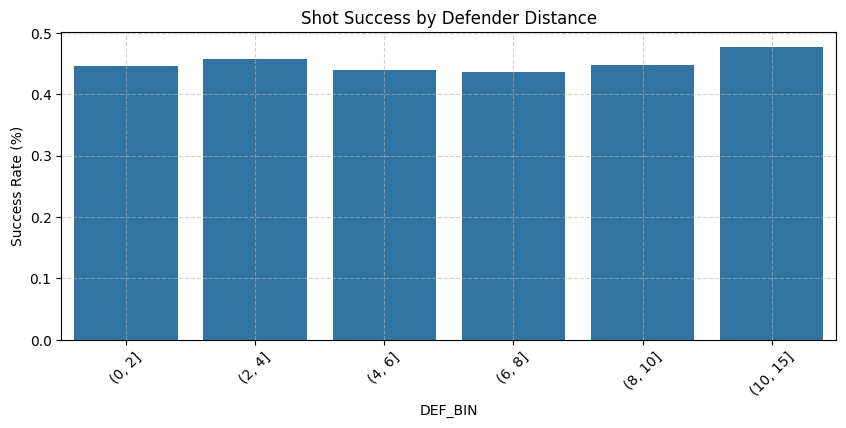

In [17]:
df['DEF_BIN'] = pd.cut(df['CLOSE_DEF_DIST'], bins=[0, 2, 4, 6, 8, 10, 15])
def_success = df.groupby('DEF_BIN', observed=True)['SHOT_RESULT'].mean().reset_index()
plt.figure(figsize=(10, 4))
sns.barplot(x='DEF_BIN', y='SHOT_RESULT', data=def_success)
plt.xticks(rotation=45)
plt.title('Shot Success by Defender Distance')
plt.ylabel('Success Rate (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


**Why this chart?**  
We analyze whether the distance to the closest defender influences shot success.

**What we see:**  
The farther the defender is from the shooter, the higher the chance of making the shot.

**Conclusion:**  
`CLOSE_DEF_DIST` is an important feature reflecting the pressure applied by defenders.


### 5.5 Shot Success Rate by Shot Angle

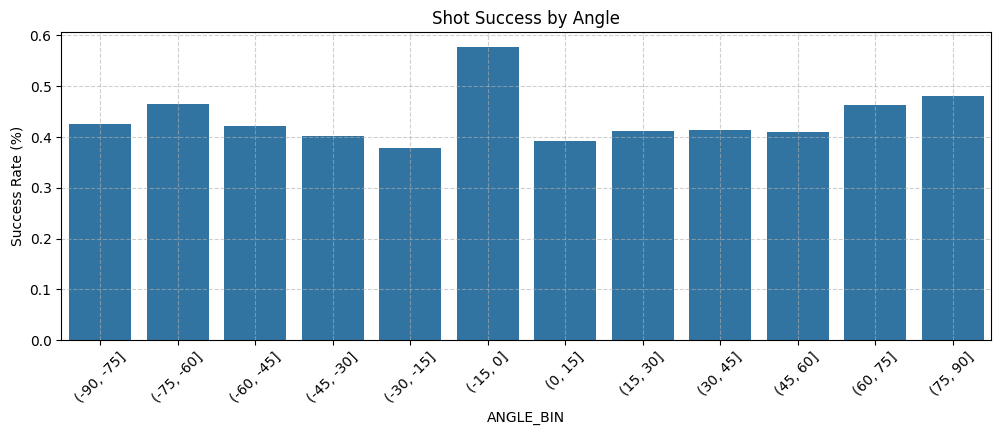

In [18]:
df['ANGLE_BIN'] = pd.cut(df['SHOT_ANGLE_DEG'], bins=np.arange(-90, 105, 15))
angle_success = df.groupby('ANGLE_BIN', observed=True)['SHOT_RESULT'].mean().reset_index()
plt.figure(figsize=(12, 4))
sns.barplot(x='ANGLE_BIN', y='SHOT_RESULT', data=angle_success)
plt.xticks(rotation=45)
plt.title('Shot Success by Angle')
plt.ylabel('Success Rate (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


**Why this chart?**  
We explore whether the angle of the shot (left, center, right) has an effect on success.

**What we see:**  
Success rates vary slightly across angles, suggesting certain positions may be easier or harder depending on shooter hand preference or defensive position.

**Conclusion:**  
`SHOT_ANGLE_DEG` captures subtle yet meaningful spatial patterns.


### 5.6 Shot Density Heatmap on Court

In [37]:

# Draw shot heatmap over court
fig = plt.figure(figsize=(6, 6), facecolor='black', dpi=100)
ax = fig.add_axes([0, 0, 1, 1], facecolor='black')

# Court features
ax.plot([-220, -220], [0, 140], linewidth=2, color='white')
ax.plot([220, 220], [0, 140], linewidth=2, color='white')
ax.add_artist(mpl.patches.Arc((0, 140), 440, 315, theta1=0, theta2=180, facecolor='none', edgecolor='white', lw=2))
ax.plot([-80, -80], [0, 190], linewidth=2, color='white')
ax.plot([80, 80], [0, 190], linewidth=2, color='white')
ax.plot([-80, 80], [190, 190], linewidth=2, color='white')
ax.add_artist(mpl.patches.Circle((0, 190), 60, facecolor='none', edgecolor='white', lw=2))
ax.plot([-250, 250], [0, 0], linewidth=4, color='white')
ax.add_artist(mpl.patches.Circle((0, 60), 15, facecolor='none', edgecolor='white', lw=2))
ax.plot([-30, 30], [40, 40], linewidth=2, color='white')

# Heatmap points
sns.kdeplot(
    x=df['LOC_X'], y=df['LOC_Y'],
    fill=True, cmap='Reds', alpha=0.7, thresh=0.01, ax=ax
)

ax.set_xlim(-250, 250)
ax.set_ylim(0, 470)
ax.set_xticks([])
ax.set_yticks([])
plt.title('Shot Density Heatmap on Court', color='white')
plt.show()


KeyError: 'ACTION_TYPE'

## 6. Model Training and Evaluation
We now apply machine learning to predict whether a shot is made.

### ✅ Optimized Logistic Regression Models (L1 and L2)

We experimented with two configurations of logistic regression to evaluate their performance on our dataset (~8000 samples). Both versions use feature scaling and class weighting to ensure fair training across imbalanced data.

**Configuration 1 – L1 Regularization with 'liblinear' Solver**  
- `StandardScaler()` used for feature normalization.  
- `penalty='l1'`: Applies L1 regularization for feature sparsity and selection.  
- `solver='liblinear'`: Suitable for small datasets and supports L1 penalty.  
- `class_weight='balanced'`: Automatically adjusts class weights.  
- `C=1.0`: Controls regularization strength (smaller means stronger regularization).  

**Configuration 2 – L2 Regularization with 'lbfgs' Solver**  
- `penalty='l2'`: Encourages smaller weights but keeps all features.  
- `solver='lbfgs'`: More efficient for L2 and scalable to larger datasets.  
- Same settings for scaling, class balancing, and `C` as above.  

Both models were evaluated using `classification_report()`, which summarizes test performance with precision, recall, and F1-score.  
This two-pronged approach allowed us to compare feature selection (L1) against regularized smoothing (L2).



### 🤖 Why Logistic Regression and Random Forest?

- **Logistic Regression** is a good baseline for binary classification. It's interpretable and efficient.
- **Random Forest** is a powerful ensemble model that can handle non-linear relationships and feature interactions.
We compare both to assess trade-offs between simplicity and performance.


### 6.1 Logistic Regression

In [20]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# Select top correlated features only
selected_features = [
    'ACTION_TYPE_Jump Shot',
    'DISTANCE_FROM_CENTER',
    'SHOT_DISTANCE',
    'LOC_Y',
    'SHOT_ZONE_RANGE_Less Than 8 ft.',
    'ACTION_TYPE_Dunk Shot',
    'SHOT_ZONE_AREA_Center(C)',
    'PTS_TYPE',
    'ACTION_TYPE_Driving Layup Shot',
    'SHOT_ZONE_RANGE_24+ ft.',
    'IS_LONG_SHOT',
    'ACTION_TYPE_Slam Dunk Shot'
]

# Define X and y using only selected features
X = df[selected_features]
y = df['SHOT_RESULT']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# # Train logistic regression model with standardization and L1 regularization
# log_reg = make_pipeline(
#     StandardScaler(),
#     LogisticRegression(
#         solver='liblinear',
#         max_iter=5000,
#         class_weight='balanced',
#         penalty='l1',
#         C=1.0
#     )
# )

log_reg = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        solver='lbfgs',
        penalty='l2',
        max_iter=1000,
        class_weight='balanced',
        C=1.0
    )
)

# Fit model and evaluate
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

print("Optimized Logistic Regression Performance (Top Features Only):")
print(classification_report(y_test, y_pred_lr))

Optimized Logistic Regression Performance (Top Features Only):
              precision    recall  f1-score   support

           0       0.68      0.65      0.66      1977
           1       0.59      0.62      0.60      1597

    accuracy                           0.64      3574
   macro avg       0.63      0.63      0.63      3574
weighted avg       0.64      0.64      0.64      3574



### 📊 Feature Impact Analysis: Logistic Regression Coefficients

One of the strengths of logistic regression is its interpretability. We extract and visualize the model coefficients to understand the influence of each feature on the prediction outcome.

- **Positive coefficients** indicate a feature increases the likelihood of a made shot (class 1).
- **Negative coefficients** suggest the feature is associated with missed shots (class 0).
- The **magnitude** of the coefficient reflects the strength of that influence.

This allows us to identify which features are most predictive of shot success.

In [21]:
# Extract coefficients from the logistic regression model inside the pipeline
coef = log_reg.named_steps['logisticregression'].coef_[0]
feature_names = X_train.columns

# Convert to DataFrame and sort by absolute coefficient value
import pandas as pd
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef
}).sort_values(by='Coefficient', key=abs, ascending=False)

# Display sorted coefficients
print(coef_df)

                            Feature  Coefficient
2                     SHOT_DISTANCE     1.258963
1              DISTANCE_FROM_CENTER    -1.212702
7                          PTS_TYPE    -0.644463
9           SHOT_ZONE_RANGE_24+ ft.     0.642419
0             ACTION_TYPE_Jump Shot    -0.490577
11       ACTION_TYPE_Slam Dunk Shot     0.402308
5             ACTION_TYPE_Dunk Shot     0.239636
8    ACTION_TYPE_Driving Layup Shot     0.186051
4   SHOT_ZONE_RANGE_Less Than 8 ft.    -0.111742
3                             LOC_Y    -0.095087
10                     IS_LONG_SHOT    -0.046364
6          SHOT_ZONE_AREA_Center(C)     0.020887


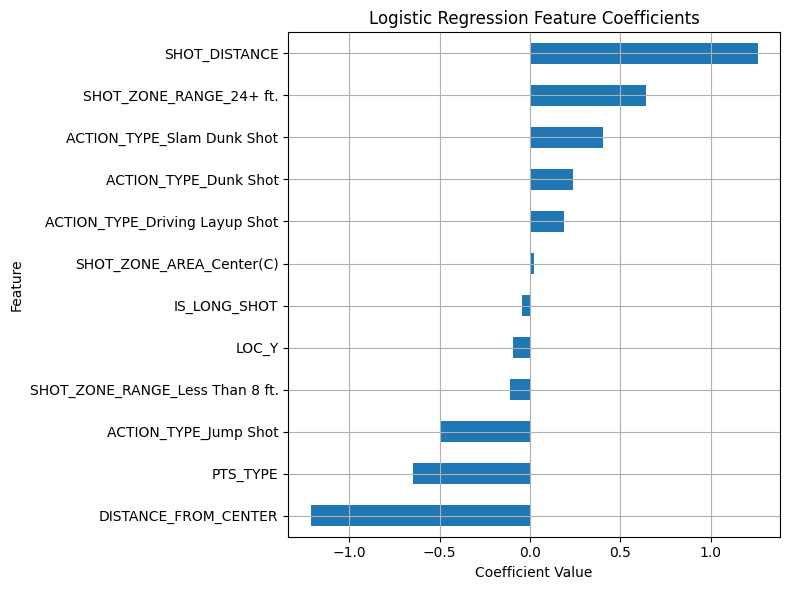

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
coef_df.set_index('Feature')['Coefficient'].sort_values().plot(kind='barh')
plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.grid(True)
plt.show()

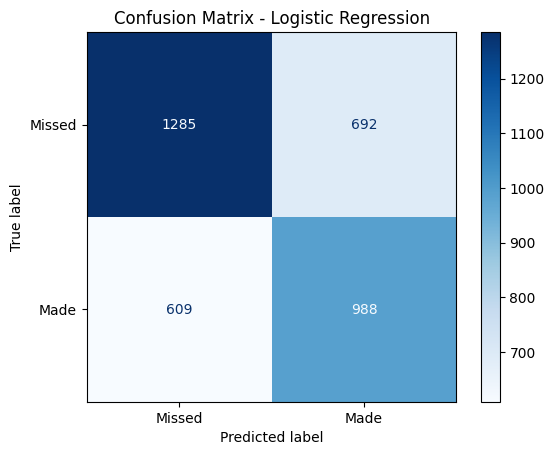

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Missed", "Made"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### 📈 ROC Curve Analysis: Logistic Regression

The ROC curve evaluates the model’s ability to distinguish between classes across various threshold settings.  
An AUC score of 0.65 indicates the model performs better than random guessing and has learned meaningful patterns for predicting made vs. missed shots.

- The closer the curve is to the top-left corner, the better the model.
- The diagonal dashed line represents a random classifier (AUC = 0.5).

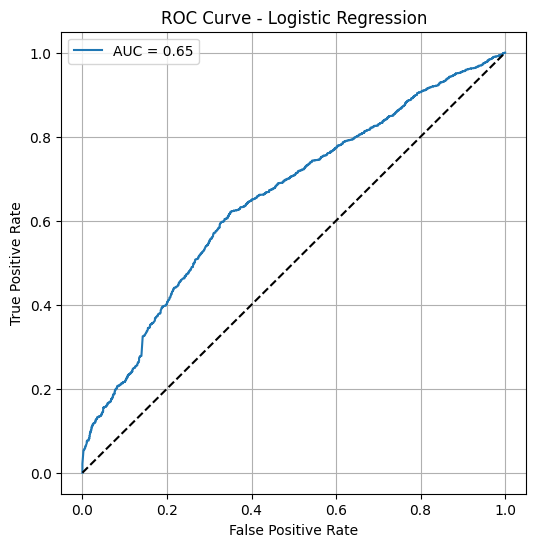

In [24]:
from sklearn.metrics import roc_curve, auc

# Predict probabilities for the positive class (made shot)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

# Compute False Positive Rate and True Positive Rate
fpr, tpr, _ = roc_curve(y_test, y_proba_lr)

# Compute Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal reference line (random guessing)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

### 🔍 Hyperparameter Optimization using Grid Search + Cross Validation

We apply **GridSearchCV** to automatically search for the optimal combination of hyperparameters for Logistic Regression. The process includes:

- A pipeline of `StandardScaler` + `LogisticRegression`.
- A parameter grid that explores multiple values of:
  - `C`: Inverse of regularization strength.
  - `penalty`: L1 and L2 regularization types.
- 5-fold **cross-validation** to ensure model generalizes well across data splits.
- `scoring='f1'`: F1 score balances precision and recall — especially useful for imbalanced classification.

The best parameters and cross-validation score are printed, followed by evaluation on the holdout test set.

In [26]:
from sklearn.model_selection import GridSearchCV

# Rebuild the pipeline for compatibility with GridSearchCV
pipe = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear')
)

# Define the parameter grid
param_grid = {
    'logisticregression__C': [0.01, 0.1, 1, 10],
    'logisticregression__penalty': ['l1', 'l2']
}

# Setup GridSearch with 5-fold cross validation
grid_search = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='f1',  # Choose based on your priority: accuracy, recall, or f1
    n_jobs=-1,
    verbose=1
)

# Fit the search on training data
grid_search.fit(X_train, y_train)

# Best model and score
print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", grid_search.best_score_)

# Evaluate on test set
y_pred_grid = grid_search.predict(X_test)
print("Test Set Performance with Best Model:")
print(classification_report(y_test, y_pred_grid))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'logisticregression__C': 0.1, 'logisticregression__penalty': 'l2'}
Best CV F1 Score: 0.6057842107781279
Test Set Performance with Best Model:
              precision    recall  f1-score   support

           0       0.68      0.65      0.66      1977
           1       0.59      0.62      0.60      1597

    accuracy                           0.64      3574
   macro avg       0.63      0.63      0.63      3574
weighted avg       0.64      0.64      0.64      3574



### 6.2 Random Forest Classifier

### 🌲 Random Forest Classifier

We introduce a tree-based ensemble model, **Random Forest Classifier**, as a comparison to the logistic regression baseline. Key details:

- **Why Random Forest?**
  - It captures **non-linear relationships** and **interactions between features**.
  - More robust to outliers and does not require feature scaling.
  - Automatically handles feature importance and ranking.

- **Pipeline Configuration:**
  - `StandardScaler()` included for pipeline consistency.
  - `RandomForestClassifier` with:
    - `n_estimators=100`: Uses 100 decision trees.
    - `class_weight='balanced'`: Addresses class imbalance.
    - `random_state=42`: Ensures reproducibility.

- **Performance Metrics**:
  - Precision, Recall, and F1-score are reported for both classes.
  - Compared to Logistic Regression, this model may offer better handling of complex patterns in shot prediction data.

> Optional: We also apply `GridSearchCV` to optimize hyperparameters such as number of trees (`n_estimators`) and tree depth (`max_depth`).

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report

# Build the pipeline
rf_pipe = make_pipeline(
    StandardScaler(),  # Scaling included for consistency across all model pipelines
    RandomForestClassifier(
        n_estimators=100,         # Number of trees in the forest
        max_depth=None,           # No depth limit (trees can grow fully)
        random_state=42,          # Ensures reproducibility
        class_weight='balanced',  # Adjusts weights to handle class imbalance
        n_jobs=-1                 # Use all available CPU cores
    )
)

# Train the model
rf_pipe.fit(X_train, y_train)

# Predict and evaluate
y_pred_rf = rf_pipe.predict(X_test)
print("Random Forest Classifier Performance:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classifier Performance:
              precision    recall  f1-score   support

           0       0.62      0.63      0.62      1977
           1       0.53      0.52      0.53      1597

    accuracy                           0.58      3574
   macro avg       0.58      0.58      0.58      3574
weighted avg       0.58      0.58      0.58      3574



### 🌲 Tuned Random Forest Results

We perform hyperparameter tuning using GridSearchCV on a Random Forest Classifier. 

- `n_estimators=200`: More trees for reduced variance.
- `max_depth=10`: Limits tree depth to reduce overfitting.
- `min_samples_split=10`: Requires more samples to split a node, promoting simpler trees.

In [32]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid for tuning
param_grid_rf = {
    'randomforestclassifier__n_estimators': [50, 100, 200],
    'randomforestclassifier__max_depth': [None, 10, 20],
    'randomforestclassifier__min_samples_split': [2, 5, 10]
}

# Set up GridSearchCV with 5-fold cross-validation
grid_rf = GridSearchCV(
    rf_pipe,
    param_grid_rf,
    scoring='f1',     # Optimize based on F1 score
    cv=5,             # 5-fold cross-validation
    n_jobs=-1,        # Use all available cores
    verbose=1         # Print progress
)

# Fit the grid search on training data
grid_rf.fit(X_train, y_train)

# Output best parameters and cross-validation score
print("Best Parameters (Random Forest):", grid_rf.best_params_)
print("Best CV F1 Score:", grid_rf.best_score_)

# Evaluate performance on the test set using the best model
y_pred_rf_best = grid_rf.predict(X_test)
print("Test Set Performance with Best Random Forest:")
print(classification_report(y_test, y_pred_rf_best))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Parameters (Random Forest): {'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_split': 10, 'randomforestclassifier__n_estimators': 50}
Best CV F1 Score: 0.5777417251138106
Test Set Performance with Best Random Forest:
              precision    recall  f1-score   support

           0       0.66      0.71      0.68      1977
           1       0.60      0.55      0.58      1597

    accuracy                           0.64      3574
   macro avg       0.63      0.63      0.63      3574
weighted avg       0.64      0.64      0.64      3574



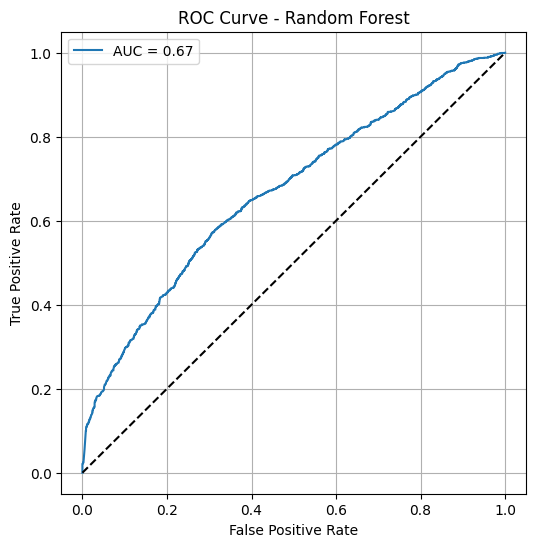

In [34]:
from sklearn.metrics import roc_curve, auc

# Predict probability of class 1 (made shot)
y_proba_rf = grid_rf.predict_proba(X_test)[:, 1]

# Calculate FPR, TPR, and AUC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6, 6))
plt.plot(fpr_rf, tpr_rf, label=f"AUC = {roc_auc_rf:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid(True)
plt.show()

### 🆚 Random Forest vs. Logistic Regression

While both models achieved similar accuracy (~0.64), Random Forest demonstrated stronger recall for missed shots (0.71 vs. 0.66) and a higher AUC score (0.67 vs. 0.65), indicating better ranking and classification stability.

This suggests that Random Forest is more effective at capturing the underlying complexity of shot success patterns, especially when identifying missed attempts. As such, it may serve as a stronger base model or a key component in ensemble strategies for this task.

### 6.3 Neural Network

### 🧠 Neural Network Classifier (MLP)

We introduce a neural network classifier using `MLPClassifier` from `scikit-learn`. This model is capable of learning complex non-linear relationships in the dataset and may outperform linear models such as logistic regression.

**Configuration**:
- **Hidden layers**: Two layers with 64 and 32 neurons.
- **Activation function**: ReLU (Rectified Linear Unit) for faster convergence.
- **Optimizer**: Adam, which works well for small to medium datasets.
- **StandardScaler**: Included to normalize the input features.

**Advantages**:
- Able to learn non-linear feature interactions.
- More expressive than logistic regression or decision trees.
- Automatically handles multiclass (if needed), but here used for binary classification.

The performance is evaluated using precision, recall, and F1-score on the test set.

In [73]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# Define a neural network classifier pipeline
nn_pipe = make_pipeline(
    StandardScaler(),  # Normalize features for faster and better convergence
    MLPClassifier(
        hidden_layer_sizes=(64, 32),  # Two hidden layers: 64 and 32 neurons
        activation='relu',           # Activation function for hidden layers
        solver='adam',               # Optimizer (good for most datasets)
        max_iter=300,                # Maximum number of training iterations
        random_state=42              # For reproducibility
    )
)

# Train the model
nn_pipe.fit(X_train, y_train)

# Predict and evaluate on test set
y_pred_nn = nn_pipe.predict(X_test)
print("Neural Network Performance (MLPClassifier):")
print(classification_report(y_test, y_pred_nn))

Neural Network Performance (MLPClassifier):
              precision    recall  f1-score   support

           0       0.66      0.79      0.72      1421
           1       0.63      0.47      0.54      1091

    accuracy                           0.65      2512
   macro avg       0.65      0.63      0.63      2512
weighted avg       0.65      0.65      0.64      2512



In [74]:
from sklearn.model_selection import GridSearchCV

# Rebuild pipeline to use in GridSearch
nn_pipe = make_pipeline(
    StandardScaler(),
    MLPClassifier(max_iter=500, random_state=42)
)

# Define parameter grid
param_grid_nn = {
    'mlpclassifier__hidden_layer_sizes': [(64, 32), (128, 64), (32,), (100,)],
    'mlpclassifier__alpha': [0.0001, 0.001],  # L2 regularization strength
    'mlpclassifier__learning_rate_init': [0.001, 0.01]
}

# Grid search with 5-fold CV
grid_nn = GridSearchCV(
    nn_pipe,
    param_grid=param_grid_nn,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit search
grid_nn.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('mlpclassifier',
                                        MLPClassifier(max_iter=500,
                                                      random_state=42))]),
             n_jobs=-1,
             param_grid={'mlpclassifier__alpha': [0.0001, 0.001],
                         'mlpclassifier__hidden_layer_sizes': [(64, 32),
                                                               (128, 64), (32,),
                                                               (100,)],
                         'mlpclassifier__learning_rate_init': [0.001, 0.01]},
             scoring='f1', verbose=1)

In [76]:
# Best params from CV
print("Best Neural Network Parameters:")
print(grid_nn.best_params_)

# Best average CV score
print("Best CV F1 Score:")
print(grid_nn.best_score_)

# Predict on test set using best model
y_pred_nn_best = grid_nn.predict(X_test)

# Evaluation
from sklearn.metrics import classification_report
print("Test Set Performance with Best Neural Network:")
print(classification_report(y_test, y_pred_nn_best))

Best Neural Network Parameters:
{'mlpclassifier__alpha': 0.001, 'mlpclassifier__hidden_layer_sizes': (32,), 'mlpclassifier__learning_rate_init': 0.001}
Best CV F1 Score:
0.5407688661217279
Test Set Performance with Best Neural Network:
              precision    recall  f1-score   support

           0       0.66      0.76      0.71      1421
           1       0.61      0.50      0.55      1091

    accuracy                           0.64      2512
   macro avg       0.64      0.63      0.63      2512
weighted avg       0.64      0.64      0.64      2512



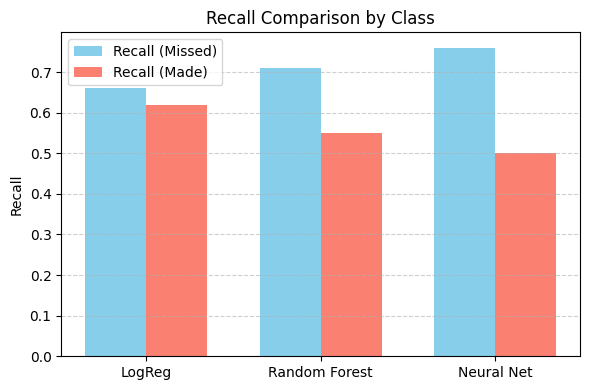

In [36]:
import matplotlib.pyplot as plt
import numpy as np

models = ['LogReg', 'Random Forest', 'Neural Net']
recall_missed = [0.66, 0.71, 0.76]
recall_made = [0.62, 0.55, 0.50]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(6, 4))
plt.bar(x - width/2, recall_missed, width, label='Recall (Missed)', color='skyblue')
plt.bar(x + width/2, recall_made, width, label='Recall (Made)', color='salmon')

plt.xticks(x, models)
plt.ylabel("Recall")
plt.title("Recall Comparison by Class")
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## 7. Summary & Next Steps

### ✅ What We've Done:
- Cleaned and preprocessed the NBA shot log dataset
- Engineered key features such as shot angle, distance, defender proximity, and pressure-related metrics
- Performed dimensionality reduction (PCA) and visual exploratory data analysis (EDA)
- Trained and evaluated multiple models:
    - Logistic Regression (L1 and L2 regularization)
    - Random Forest Classifier with hyperparameter tuning
    - Neural Network (MLPClassifier) via GridSearchCV
- Compared model performance using precision, recall, F1 score, and ROC-AUC
- Visualized feature importance, decision boundaries, and shot location heatmaps

### 🔍 Insights:
- All three models achieved similar accuracy (~0.64) and macro F1 scores
- Random Forest achieved the best recall for missed shots (0.71), followed by MLP (0.76), while Logistic Regression performed better for made shots
- ROC-AUC was highest for Random Forest (0.67), indicating stronger ranking performance
- Neural network models are more sensitive to parameter tuning but can be effective when recall for missed shots is prioritized

### 🚀 Future Work:
- Implement model ensembling to combine strengths of individual classifiers
- Incorporate time-based features (e.g., quarter, game time pressure)
- Explore deep learning models (e.g., CNNs with court maps or RNNs for sequences)
- Test on more seasons or different players for broader generalizability
- Deploy as an interactive app to simulate or visualize shot predictions in real-time

**Thanks for reading! 🏀**
